# Market Technical Indicators

## Overview

This notebook demonstrates the public functions in `market_technical_indicators` using observed AAPL dollar bars.

- Problem: irregular dollar-bar price and volume observations need consistent breadth, momentum, overlap, and volatility features for downstream modeling.
- Approach: calculate every FinanceToolkit technical indicator for each observed dollar bar, save the complete feature table, and inspect representative indicators from each category.

## Observed Data

This cell defines the observed AAPL dollar-bar request and the technical-indicator output settings.

- `data_path` identifies `../../data/research_data/market/features/aapl_dollar_bar_2025-01-01_2025-12-31.parquet` as the source file.
- `window` sets the shared lookback to `14` dollar bars for indicators that accept a window.
- `plot_rows` limits each visualization to the most recent `2000` dollar bars while leaving the saved dataset complete.
- `output_path` is `None`, so the dataset is saved beside the source at `../../data/research_data/market/features/aapl_technical_indicators_2025-01-01_2025-12-31.parquet`.
- `end` contains the UTC timestamp of the final observation in each dollar bar.
- `start` contains the UTC timestamp of the first observation in each dollar bar.
- `symbol` identifies the instrument represented by the bar.
- `open` contains the first observed price in dollars.
- `high` contains the highest observed price in dollars.
- `low` contains the lowest observed price in dollars.
- `close` contains the final observed price in dollars.
- `volume` contains the total observed share volume.
- `dollar_value` contains the total derived dollar value.
- `ticks` contains the number of source trade observations.
- `buy_volume` contains the share volume assigned a positive direction.
- `sell_volume` contains the share volume assigned a negative direction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data_preprocessing.market_technical_indicators import (
    save_market_technical_indicators,
)

data_path = Path(
    "../../data/research_data/market/features/"
    "aapl_dollar_bar_2025-01-01_2025-12-31.parquet"
)
window = 14
plot_rows = 2000
output_path = None

## Technical Indicator Feature Table

This cell calculates and saves every FinanceToolkit technical indicator for the observed dollar bars, then reports the model-ready feature fields.

- `start` identifies the UTC start timestamp retained from each source dollar bar.
- `end` identifies the UTC end timestamp retained from each source dollar bar.
- `symbol` identifies `AAPL` as the equity shared by all feature rows.
- The remaining columns contain derived breadth, momentum, overlap, and volatility indicators; initial lookback rows can contain missing values.
- `saved_path` identifies the parquet file written to the market feature directory.

In [2]:
saved_path = save_market_technical_indicators(
    data_path=data_path,
    window=window,
    output_path=output_path,
)

technical_features = pd.read_parquet(saved_path)
print(saved_path)
display(technical_features.head())

2026-08-04 16:14:22.965 | INFO     | src.data_preprocessing.market_technical_indicators:save_market_technical_indicators:146 - Saved 156779 technical-indicator rows to ../../data/research_data/market/features/aapl_technical_indicators_2025-01-01_2025-12-31.parquet.


../../data/research_data/market/features/aapl_technical_indicators_2025-01-01_2025-12-31.parquet


,start,end,symbol,McClellan Oscillator,Advancers - Decliners,On-Balance Volume,Accumulation/Distribution Line,Chaikin Oscillator,TRIN,New Highs - New Lows,...,Bollinger Band Middle,Bollinger Band Lower,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower
0,2025-01-02 13:45:58.902948+00:00,2025-01-02 14:30:01.004279+00:00,AAPL,0.0000,0.00,NaN,-2037.8198,0.0000,NaN,0,...,NaN,NaN,1.110,1.1100,251.1300,248.9100,246.6900,NaN,NaN,NaN
1,2025-01-02 14:30:01.004306+00:00,2025-01-02 14:30:02.119118+00:00,AAPL,12.4325,248.65,-2059.0,-3626.1912,-505.3909,NaN,-1,...,NaN,NaN,0.350,0.7300,250.3353,248.8753,247.4153,NaN,NaN,NaN
2,2025-01-02 14:30:02.129080+00:00,2025-01-02 14:30:02.891073+00:00,AAPL,22.9971,248.59,-4072.0,-5639.1912,-1306.6971,NaN,-1,...,NaN,NaN,0.125,0.5283,249.8940,248.8373,247.7806,NaN,NaN,NaN
3,2025-01-02 14:30:02.929026+00:00,2025-01-02 14:30:04.394582+00:00,AAPL,31.9159,248.61,-2054.0,-6311.8579,-1729.7438,NaN,0,...,NaN,NaN,0.150,0.4338,249.6745,248.8070,247.9395,NaN,NaN,NaN
4,2025-01-02 14:30:04.394604+00:00,2025-01-02 14:30:05.084156+00:00,AAPL,39.3804,248.58,-4066.0,-6982.5246,-1958.9529,NaN,-1,...,NaN,NaN,0.060,0.3590,249.4947,248.7767,248.0587,NaN,NaN,NaN


## Breadth Indicators

Breadth indicators summarize how price and volume participation evolve across the observed dollar bars. This cell selects three representative breadth features from the saved table.

- `On-Balance Volume` accumulates share volume according to the direction of each closing-price change.
- `Accumulation/Distribution Line` combines the close location within the dollar-bar range with share volume.
- `Chaikin Oscillator` reports momentum in the accumulation/distribution measure.

In [3]:
breadth_columns = [
    "On-Balance Volume",
    "Accumulation/Distribution Line",
    "Chaikin Oscillator",
]
breadth_features = technical_features.set_index("end")[breadth_columns]
display(breadth_features.tail())

,On-Balance Volume,Accumulation/Distribution Line,Chaikin Oscillator
end,,,
2025-12-30 20:59:29.259626+00:00,2567901.0,4.513409e+06,-909.1344
2025-12-30 20:59:37.473615+00:00,2566039.0,4.511961e+06,-1536.8534
2025-12-30 20:59:44.068102+00:00,2564138.0,4.512480e+06,-1488.9707
2025-12-30 20:59:48.950330+00:00,2562297.0,4.511559e+06,-1626.9078
2025-12-30 20:59:56.362996+00:00,2564185.0,4.513447e+06,-934.7086


## Breadth Indicator Trends

This cell visualizes the most recent breadth indicators on independent scales.

- The horizontal axes identify the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The vertical axes report cumulative share volume, accumulation/distribution volume, and oscillator volume on independent scales.

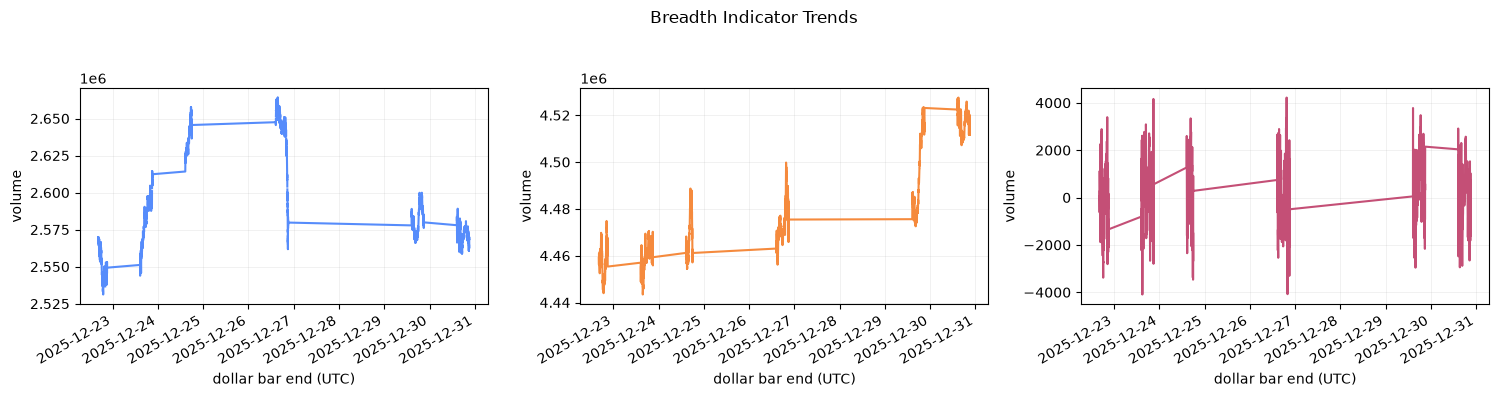

In [4]:
breadth_axes = breadth_features.tail(plot_rows).plot(
    subplots=True,
    layout=(1, 3),
    figsize=(15, 4),
    legend=False,
)
for axis in breadth_axes.ravel():
    axis.set_xlabel("dollar bar end (UTC)")
    axis.set_ylabel("volume")
    axis.grid(alpha=0.25)

plt.suptitle("Breadth Indicator Trends")
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Momentum Indicators

Momentum indicators describe the direction and strength of recent dollar-bar price changes. This cell selects an oscillator and the two moving-average convergence-divergence paths.

- `Relative Strength Index` measures recent upward price changes relative to downward changes on a scale from `0` to `100`.
- `MACD Line` reports the difference between the fast and slow exponential moving averages in dollars.
- `MACD Signal Line` smooths the MACD line in dollars to support directional comparisons.

In [5]:
momentum_columns = [
    "Relative Strength Index",
    "MACD Line",
    "MACD Signal Line",
]
momentum_features = technical_features.set_index("end")[momentum_columns]
display(momentum_features.tail())

,Relative Strength Index,MACD Line,MACD Signal Line
end,,,
2025-12-30 20:59:29.259626+00:00,49.2063,0.0051,0.0076
2025-12-30 20:59:37.473615+00:00,30.2632,-0.0048,0.0051
2025-12-30 20:59:44.068102+00:00,30.6667,-0.0145,0.0012
2025-12-30 20:59:48.950330+00:00,26.9231,-0.0239,-0.0038
2025-12-30 20:59:56.362996+00:00,40.6977,-0.0255,-0.0082


## Momentum Indicator Trends

This cell visualizes the most recent relative-strength and MACD observations.

- The horizontal axes identify the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The upper vertical axis reports the relative strength index from `0` to `100`, with `30` and `70` as common reference levels.
- The lower vertical axis reports the MACD and signal lines in dollars, with zero as the direction reference.

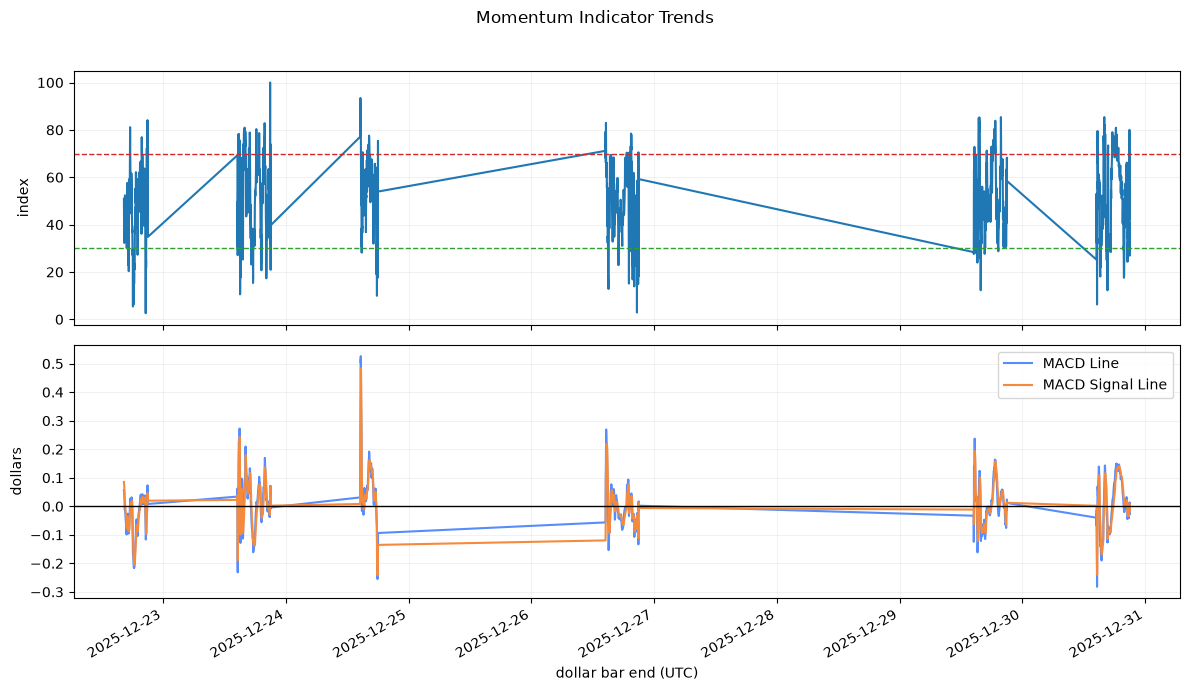

In [6]:
momentum_plot = momentum_features.tail(plot_rows)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
momentum_plot["Relative Strength Index"].plot(
    ax=axes[0],
    color="tab:blue",
)
axes[0].axhline(70, color="tab:red", linestyle="--", linewidth=1)
axes[0].axhline(30, color="tab:green", linestyle="--", linewidth=1)
axes[0].set_ylabel("index")
axes[0].grid(alpha=0.25)
momentum_plot[["MACD Line", "MACD Signal Line"]].plot(ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("dollar bar end (UTC)")
axes[1].set_ylabel("dollars")
axes[1].grid(alpha=0.25)

plt.suptitle("Momentum Indicator Trends")
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Overlap Indicators

Overlap indicators smooth or weight recent dollar-bar prices to expose the prevailing price level. This cell selects three comparable price-based features.

- `Simple Moving Average (SMA)` reports the unweighted mean closing price in dollars over the lookback window.
- `Exponential Moving Average (EMA)` reports a closing-price average in dollars that weights recent bars more heavily.
- `Volume Weighted Average Price (VWAP)` reports the average price in dollars weighted by share volume.

In [7]:
overlap_columns = [
    "Simple Moving Average (SMA)",
    "Exponential Moving Average (EMA)",
    "Volume Weighted Average Price (VWAP)",
]
overlap_features = technical_features.set_index("end")[overlap_columns]
display(overlap_features.tail())

,Simple Moving Average (SMA),Exponential Moving Average (EMA),Volume Weighted Average Price (VWAP)
end,,,
2025-12-30 20:59:29.259626+00:00,273.1464,273.1390,273.1481
2025-12-30 20:59:37.473615+00:00,273.1357,273.1231,273.1407
2025-12-30 20:59:44.068102+00:00,273.1254,273.1060,273.1292
2025-12-30 20:59:48.950330+00:00,273.1125,273.0879,273.1172
2025-12-30 20:59:56.362996+00:00,273.1068,273.0815,273.1089


## Overlap Indicator Trends

This cell compares the most recent price averages on a shared scale.

- The horizontal axis identifies the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The vertical axis reports the simple, exponential, and volume-weighted average prices in dollars.
- The three colored lines encode the smoothing or weighting method used for each price path.

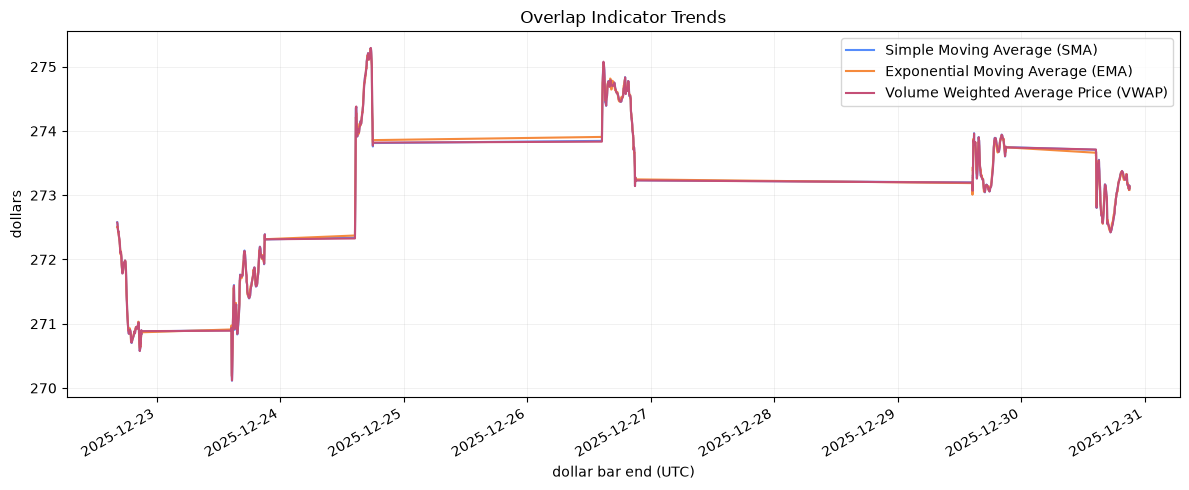

In [8]:
overlap_axis = overlap_features.tail(plot_rows).plot(figsize=(12, 5))
overlap_axis.set_xlabel("dollar bar end (UTC)")
overlap_axis.set_ylabel("dollars")
overlap_axis.set_title("Overlap Indicator Trends")
overlap_axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Volatility Indicators

Volatility indicators describe the recent price envelope and range of the observed dollar bars. This cell selects two Bollinger boundaries and average true range.

- `Bollinger Band Upper` reports the upper volatility boundary in dollars around the rolling mean.
- `Bollinger Band Lower` reports the lower volatility boundary in dollars around the rolling mean.
- `Average True Range` reports the smoothed dollar range, including gaps between consecutive bars.

In [9]:
volatility_columns = [
    "Bollinger Band Upper",
    "Bollinger Band Lower",
    "Average True Range",
]
volatility_features = technical_features.set_index("end")[
    volatility_columns
]
display(volatility_features.tail())

,Bollinger Band Upper,Bollinger Band Lower,Average True Range
end,,,
2025-12-30 20:59:29.259626+00:00,273.1837,273.1091,0.0386
2025-12-30 20:59:37.473615+00:00,273.2108,273.0606,0.0439
2025-12-30 20:59:44.068102+00:00,273.2315,273.0192,0.0443
2025-12-30 20:59:48.950330+00:00,273.2459,272.9791,0.0461
2025-12-30 20:59:56.362996+00:00,273.2455,272.9680,0.0496


## Volatility Indicator Trends

This cell visualizes the most recent Bollinger envelope and average true range.

- The horizontal axes identify the UTC endpoint of each of the most recent `plot_rows` dollar bars.
- The upper vertical axis reports the upper and lower Bollinger boundaries in dollars.
- The lower vertical axis reports average true range in dollars as a positive range measure.

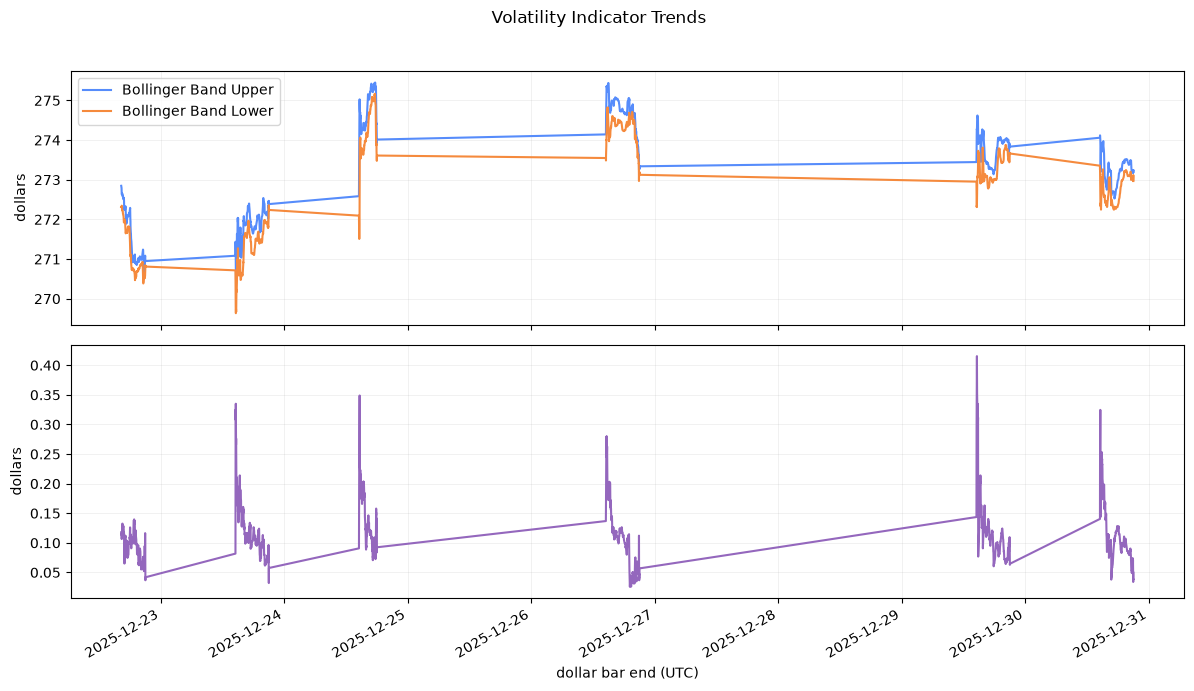

In [10]:
volatility_plot = volatility_features.tail(plot_rows)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
volatility_plot[["Bollinger Band Upper", "Bollinger Band Lower"]].plot(
    ax=axes[0]
)
axes[0].set_ylabel("dollars")
axes[0].grid(alpha=0.25)
volatility_plot["Average True Range"].plot(
    ax=axes[1],
    color="tab:purple",
)
axes[1].set_xlabel("dollar bar end (UTC)")
axes[1].set_ylabel("dollars")
axes[1].grid(alpha=0.25)

plt.suptitle("Volatility Indicator Trends")
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()